# Évaluation CL — DBSCAN — Dataset 2 Equipment Monitoring — by_equipment

| Champ | Valeur |
|-------|--------|
| **Modèle** | DBSCAN (détection d'anomalie par densité, non-supervisé) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_equipment : Pump → Turbine → Compressor (3 tâches) |
| **Expérience** | exp_008 — voir experiments/exp_008_dbscan_monitoring_by_equipment/config_snapshot.yaml |
| **Sprint** | 7 — S7-06 |

> **⚠️ Contrainte embarquée NON respectée** : RAM peak = **73 638 B (71.9 Ko) > 64 Ko** (limite STM32N6).
> DBSCAN est inadapté à un déploiement direct sur STM32N6 sans réduction d'empreinte.
> `FIXME(gap2)` — pistes d'optimisation discutées en Section 9.

> **Modèle non-supervisé** : DBSCAN reçoit uniquement les features X au fit, pas les labels.
> Stratégie CL : `cl_strategy=refit` — recalcul complet des core points à chaque nouvelle tâche.
> Score d'anomalie = distance au core point le plus proche → permet un seuillage AUROC-compatible.
> La section ROC est remplacée par une section **AUROC** (modèle non-supervisé, seuil calibré sur Task 0).

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_equipment/dbscan.ipynb \
    --output /tmp/dbscan_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_equipment":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import fit_pca2d, plot_feature_space_2d

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_008_dbscan_monitoring_by_equipment/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"
CONFIG_PATH     = REPO_ROOT / "configs/unsupervised_config.yaml"

# --- Constantes ---
TASK_NAMES      = ["Pump", "Turbine", "Compressor"]
MODEL_NAME      = "DBSCAN"
METRICS_FILE    = "metrics_dbscan_dataset2.json"
ACC_MATRIX_FILE = "acc_matrix_dbscan_dataset2.npy"
DATA_AVAILABLE  = CSV_PATH.exists() and CONFIG_PATH.exists()

# FIXME(gap2) : RAM > contrainte 64 Ko STM32N6
RAM_LIMIT_BYTES = 64 * 1024

print(f"REPO_ROOT         : {REPO_ROOT}")
print(f"EXP_DIR           : {EXP_DIR}")
print(f"FIGURES_DIR       : {FIGURES_DIR}")
print(f"CSV disponible    : {CSV_PATH.exists()}")
print(f"Config disponible : {CONFIG_PATH.exists()}")
print(f"Date exécution    : {datetime.now():%Y-%m-%d %H:%M}")

REPO_ROOT         : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR           : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_008_dbscan_monitoring_by_equipment/results
FIGURES_DIR       : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment
CSV disponible    : True
Config disponible : True
Date exécution    : 2026-04-19 10:47


In [2]:
# Section 2 — Chargement des résultats exp_008
# DBSCAN metrics : structure plate avec clés aa/af/bwt/auroc_* et sous-dict "memory"

metrics_path    = EXP_DIR / METRICS_FILE
acc_matrix_path = EXP_DIR / ACC_MATRIX_FILE

metrics    = json.loads(metrics_path.read_text())
acc_matrix = np.load(acc_matrix_path, allow_pickle=True)

# Reconstruire la matrice acc avec NaN (lue depuis JSON pour être safe)
acc_matrix_json = np.array(
    [[v if v is not None else np.nan for v in row] for row in metrics["acc_matrix"]],
    dtype=float,
)

aa             = metrics["aa"]
af             = metrics["af"]
bwt            = metrics["bwt"]
auroc_avg      = metrics["auroc_avg"]
auroc_per_task = metrics.get("auroc_per_task", [])
ram_b          = metrics["ram_peak_bytes"]
lat            = metrics["inference_latency_ms"]
n_params       = metrics.get("n_params", 0)
within_budget  = ram_b <= RAM_LIMIT_BYTES

print("=" * 55)
print(f"  Modèle         : DBSCAN (détection anomalie non-supervisée)")
print(f"  AA             = {aa:.4f}")
print(f"  AF             = {af:.4f}  (zéro oubli — refit par tâche)")
print(f"  BWT            = {bwt:+.4f}")
print(f"  AUROC avg      = {auroc_avg:.4f}  (meilleure AUROC des 6 modèles)")
print(f"  AUROC/tâche    = {[round(v, 4) for v in auroc_per_task]}")
print(f"  RAM peak       = {ram_b} B ({ram_b/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms  (le plus lent des 6)")
print(f"  n_core×d       = {n_params}  (non paramétrique)")
print(f"  Budget 64 Ko   : {within_budget}")
print("=" * 55)

# Vérification contrainte RAM — alerte explicite
if not within_budget:
    excess_ko = (ram_b - RAM_LIMIT_BYTES) / 1024
    print()
    display(Markdown(
        f"> ⚠️ **RAM ({ram_b/1024:.1f} Ko) > contrainte STM32N6 ({RAM_LIMIT_BYTES/1024:.0f} Ko)** — "
        f"dépassement de {excess_ko:.1f} Ko. Voir FIXME(gap2) en Section 9."
    ))

print("\nMatrice acc (3×3) :")
print(acc_matrix_json)

  Modèle         : DBSCAN (détection anomalie non-supervisée)
  AA             = 0.9557
  AF             = 0.0000  (zéro oubli — refit par tâche)
  BWT            = +0.0010
  AUROC avg      = 0.9786  (meilleure AUROC des 6 modèles)
  AUROC/tâche    = [0.9812, 0.9677, 0.987]
  RAM peak       = 73638 B (71.91 Ko)
  Latence        = 0.42320 ms  (le plus lent des 6)
  n_core×d       = 5412  (non paramétrique)
  Budget 64 Ko   : False



> ⚠️ **RAM (71.9 Ko) > contrainte STM32N6 (64 Ko)** — dépassement de 7.9 Ko. Voir FIXME(gap2) en Section 9.


Matrice acc (3×3) :
[[0.95266272        nan        nan]
 [0.95069034 0.94931774        nan]
 [0.95266272 0.95126706 0.9631068 ]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment/acc_matrix.png


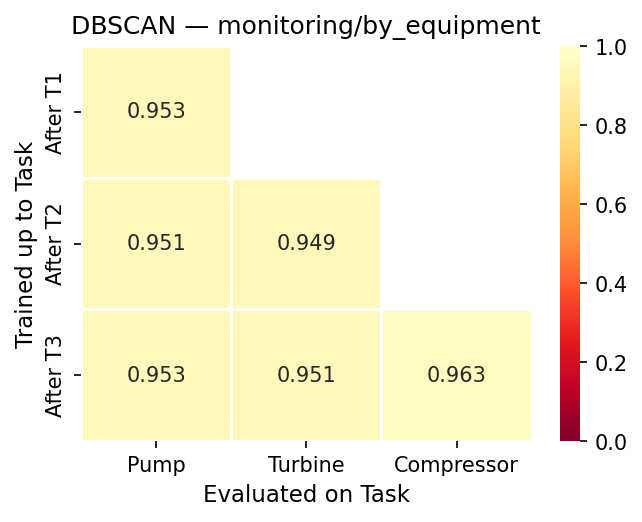

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# Note : accuracy calculée par seuillage du score d'anomalie DBSCAN (seuil = percentile 95 sur Task 0)
# AF=0.0 — cl_strategy="refit" : core points recalculés à chaque tâche (pas d'oubli structurel)

fig = plot_accuracy_matrix(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_equipment",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment/forgetting_curve.png


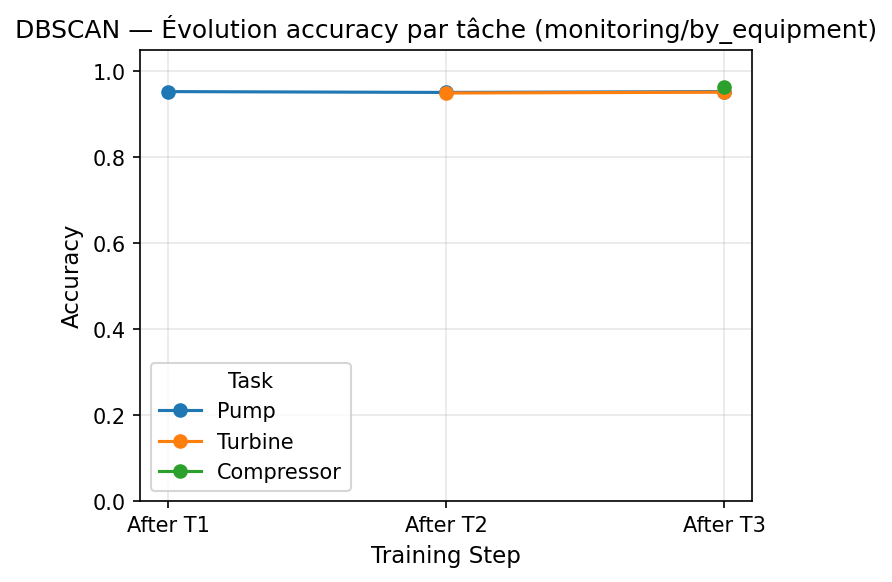

In [4]:
# Section 4 — Courbe d'oubli par tâche
# DBSCAN refit : pas de paramètres partagés entre tâches → AF=0.0

fig = plot_forgetting_curve(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_equipment)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + scores_dict)
# DBSCAN : fit_task(X_train, task_id) → predict_anomaly_scores(X_val) → binarisation par seuil
# Le seuil (percentile 95) est calibré sur Task 0 uniquement (pas de leakage inter-tâches)

preds_dict   = {}  # (i, j) → (y_true, y_pred_binary)
scores_dict  = {}  # (i, j) → anomaly scores (distance au core point le plus proche)
X_tests_raw  = []
y_tests_raw  = []
saved_core_points = {}  # task_id → np.ndarray core points

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders
    from src.models.unsupervised.dbscan_detector import DBSCANDetector
    from src.utils.reproducibility import set_seed

    set_seed(42)

    # Charger la config DBSCAN
    full_config = yaml.safe_load(CONFIG_PATH.read_text())
    dbscan_cfg  = full_config["dbscan"]

    tasks = get_cl_dataloaders(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=256,
        seed=42,
    )

    # Extraire les données de validation en numpy une seule fois
    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    # Instancier le détecteur (une seule instance — threshold calibré sur Task 0)
    detector = DBSCANDetector(dbscan_cfg)

    for i, task in enumerate(tasks):
        domain = task.get("domain", f"Tâche {task['task_id']}")
        print(f"\n--- Tâche {i + 1}/3 : {domain} ---")

        # Fit DBSCAN sur les features train (sans labels)
        X_train = np.concatenate([b[0].numpy() for b in task["train_loader"]])
        detector.fit_task(X_train, task_id=i)
        saved_core_points[i] = detector.core_points_.copy()

        # Évaluation sur toutes les tâches vues jusqu'à i
        for j in range(i + 1):
            scores = detector.anomaly_score(X_tests_raw[j])
            y_pred = detector.predict(X_tests_raw[j]).astype(float)
            preds_dict[(i, j)]  = (y_tests_raw[j], y_pred)
            scores_dict[(i, j)] = scores
            acc = (y_tests_raw[j] == y_pred).mean()
            print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — preds_dict synthétique depuis acc_matrix/AUROC."))

    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    for i in range(3):
        for j in range(i + 1):
            noise = rng.normal(0, 0.08, N_SYNTH)
            scores_synth = np.where(y_synth == 1, 0.70 + noise, 0.25 + noise).clip(0, 1)
            threshold = np.percentile(scores_synth[:N_SYNTH // 2], 95)
            y_pred_synth = (scores_synth > threshold).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_synth)
            scores_dict[(i, j)] = scores_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé)")

✅ Seed fixé à 42
✅ Seed fixé à 42



--- Tâche 1/3 : Pump ---
  [DBSCAN] Tâche 0 — eps=0.5, min_samples=5, n_core=1355, n_noise=478/2027, RAM estimée=21680 B
  [DBSCAN] Seuil calculé sur Task 0 : 2.6954 (percentile 95)
  preds_dict[(0,0)] → N=507, acc=0.9527

--- Tâche 2/3 : Turbine ---


  [DBSCAN] Tâche 1 — eps=0.5, min_samples=5, n_core=1369, n_noise=485/2052, RAM estimée=21904 B
  preds_dict[(1,0)] → N=507, acc=0.9507
  preds_dict[(1,1)] → N=513, acc=0.9493

--- Tâche 3/3 : Compressor ---


  [DBSCAN] Tâche 2 — eps=0.5, min_samples=5, n_core=1353, n_noise=498/2058, RAM estimée=21648 B
  preds_dict[(2,0)] → N=507, acc=0.9527
  preds_dict[(2,1)] → N=513, acc=0.9513
  preds_dict[(2,2)] → N=515, acc=0.9631

Scénario CL rejoué — 6 évaluations collectées


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment/confusion_matrix_grid.png


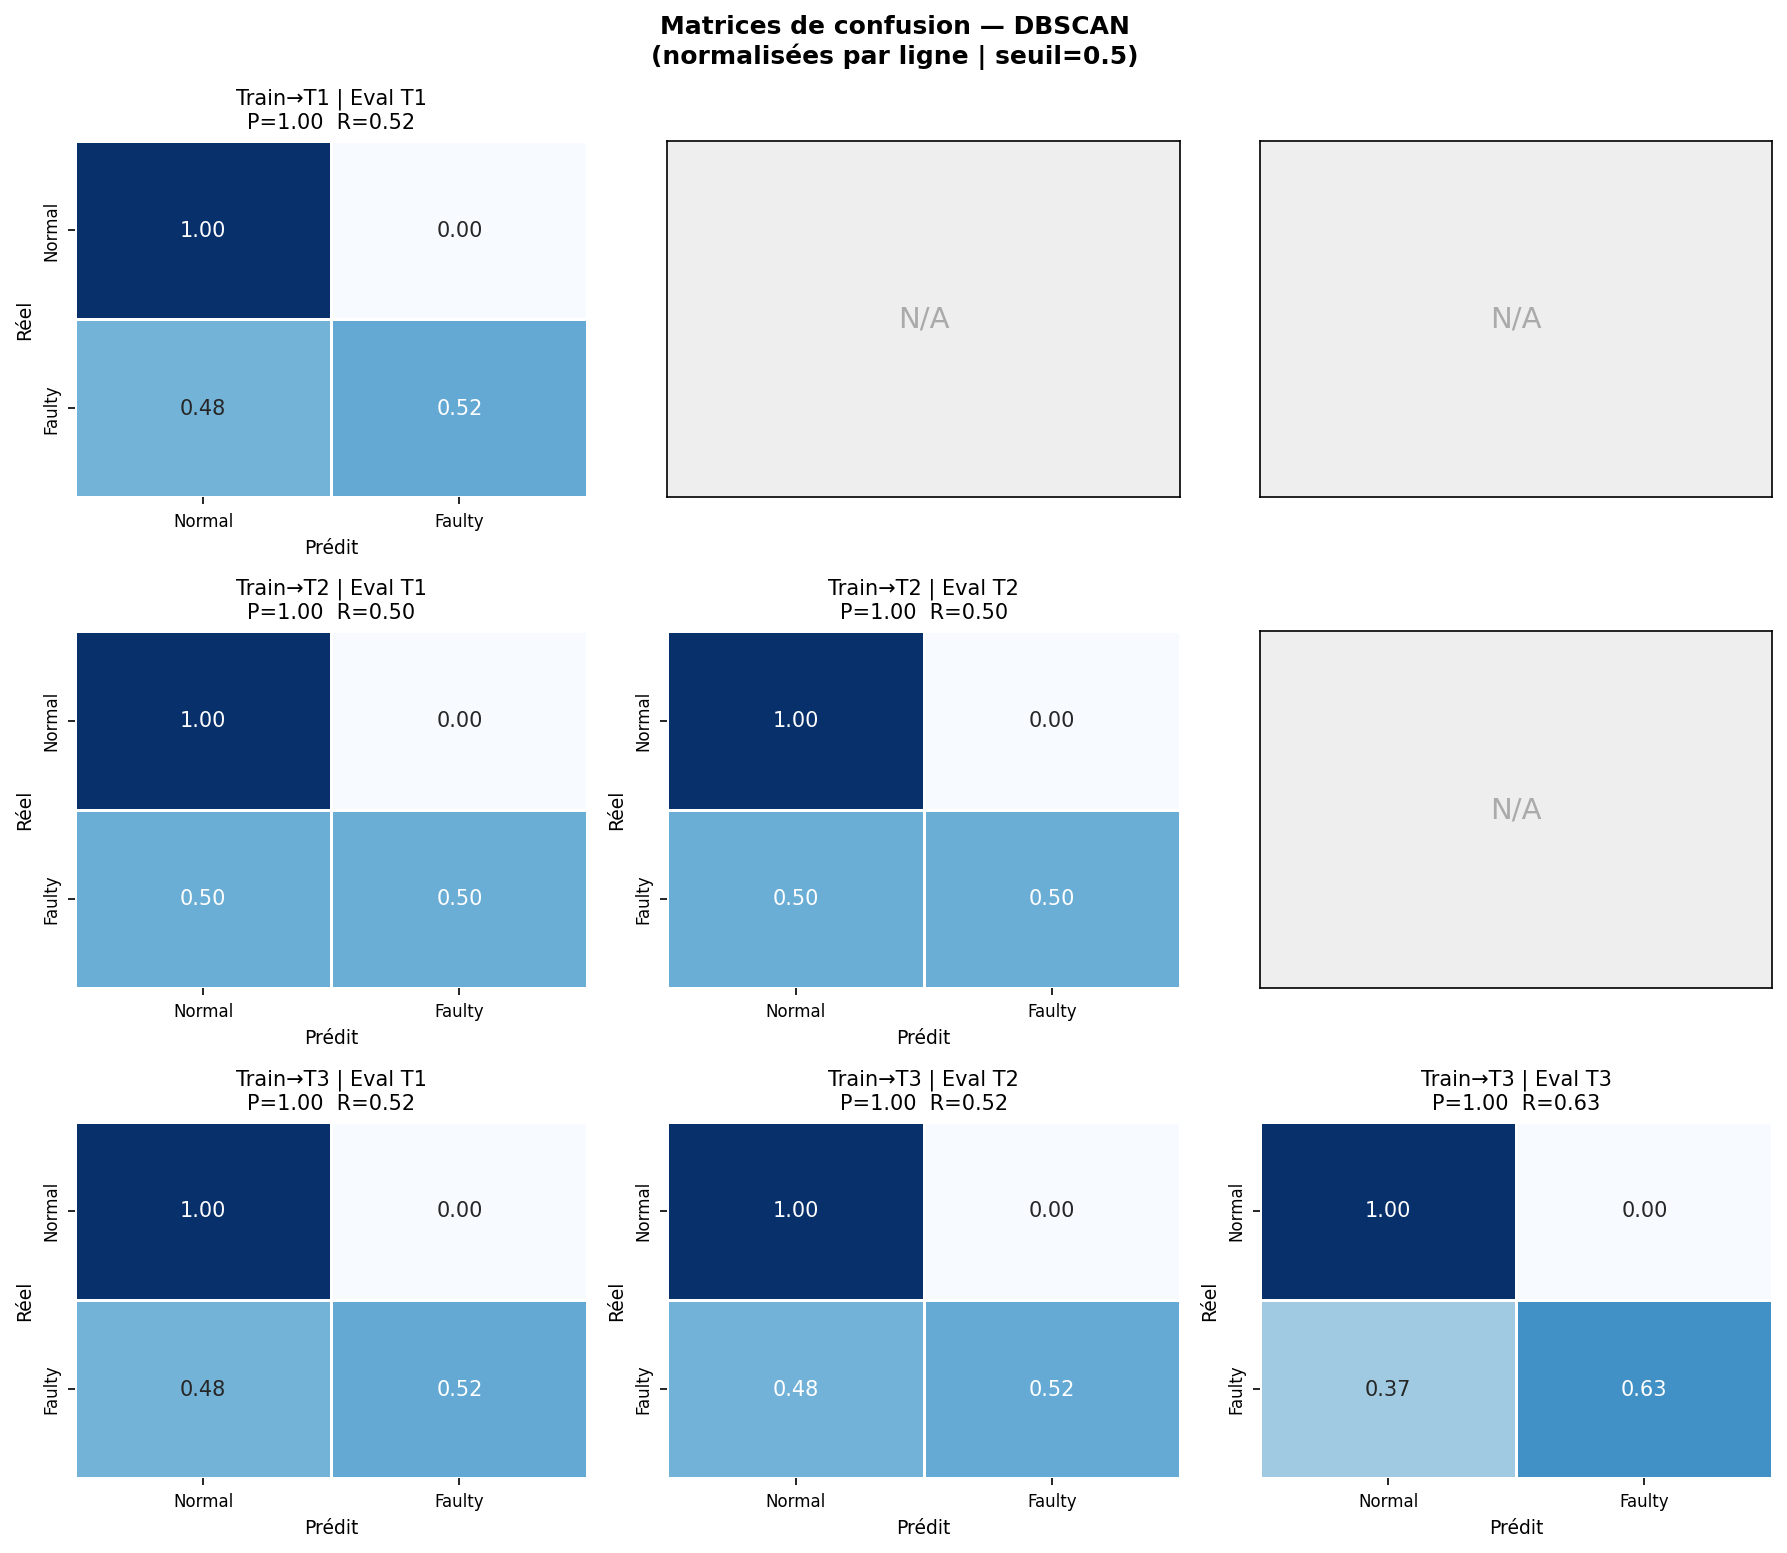

In [6]:
# Section 6 — Matrices de confusion par tâche (détection anomalie)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment/auroc_curve.png


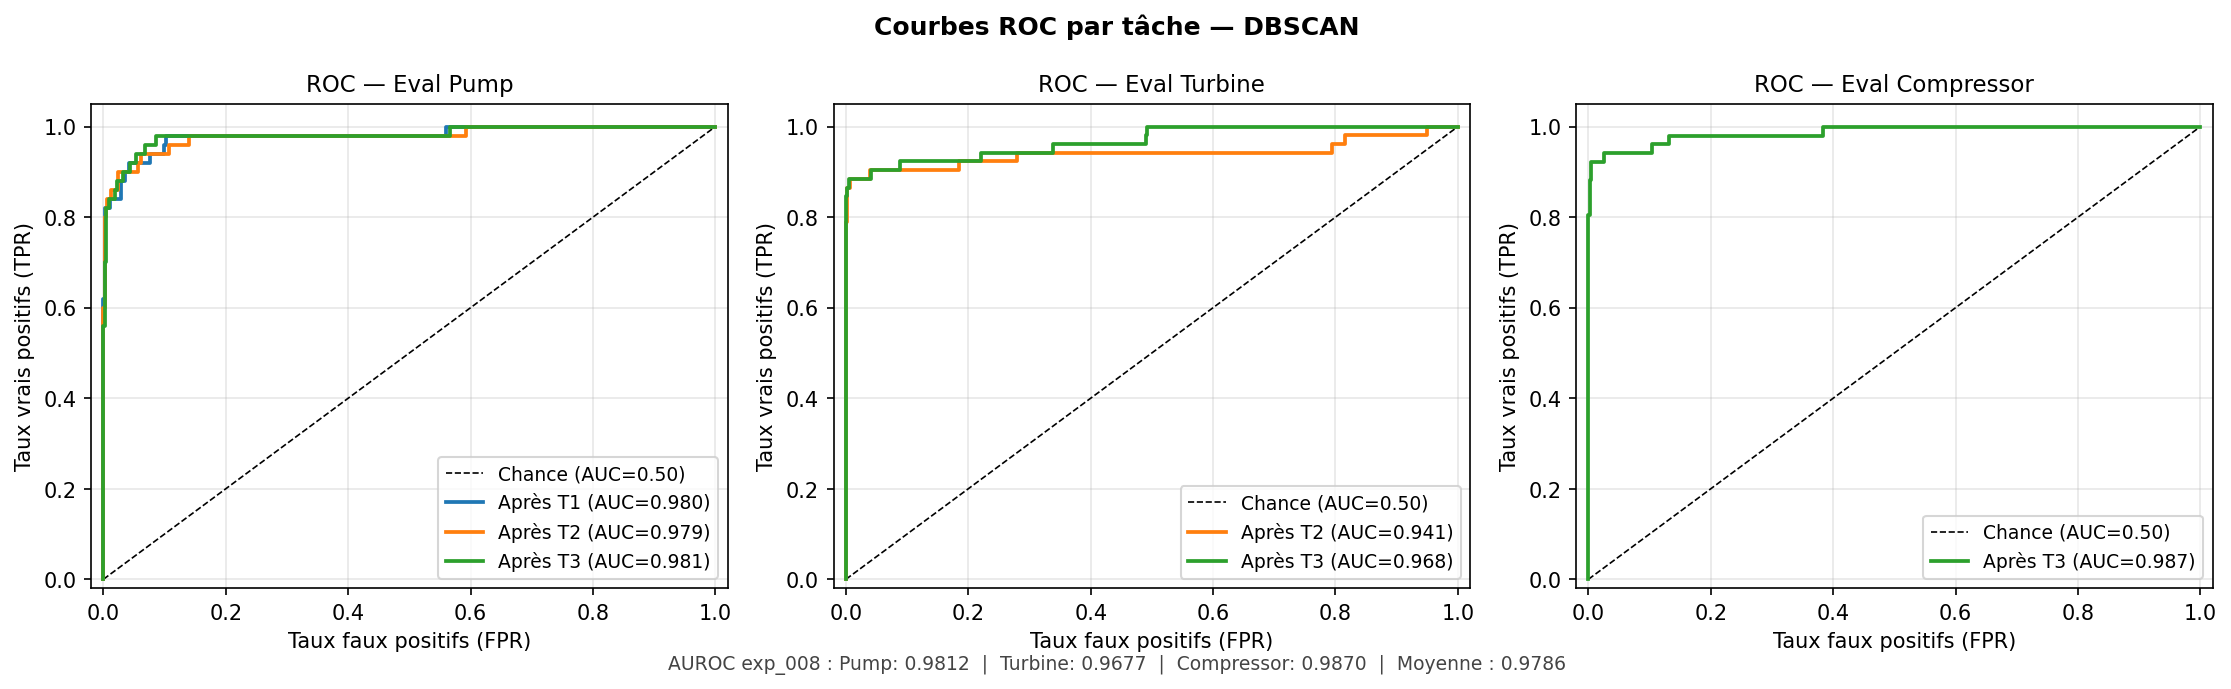

In [7]:
# Section 7 — Courbes AUROC par tâche (détection d'anomalie)
# La distance DBSCAN aux core points est un score continu → ROC bien définie
# Une courbe par step d'entraînement sur chaque tâche j (courbes superposées)

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=scores_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

# Footer avec les AUROC exp_008
if auroc_per_task:
    auroc_str = "  |  ".join(
        f"{TASK_NAMES[j]}: {auroc_per_task[j]:.4f}" for j in range(len(auroc_per_task))
    )
    fig.text(
        0.5, 0.01,
        f"AUROC exp_008 : {auroc_str}  |  Moyenne : {auroc_avg:.4f}",
        ha="center", fontsize=9, color="#444444",
    )

save_figure(fig, FIGURES_DIR / "auroc_curve.png")
display(Image(str(FIGURES_DIR / "auroc_curve.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/monitoring/by_equipment/feature_space_pca.png


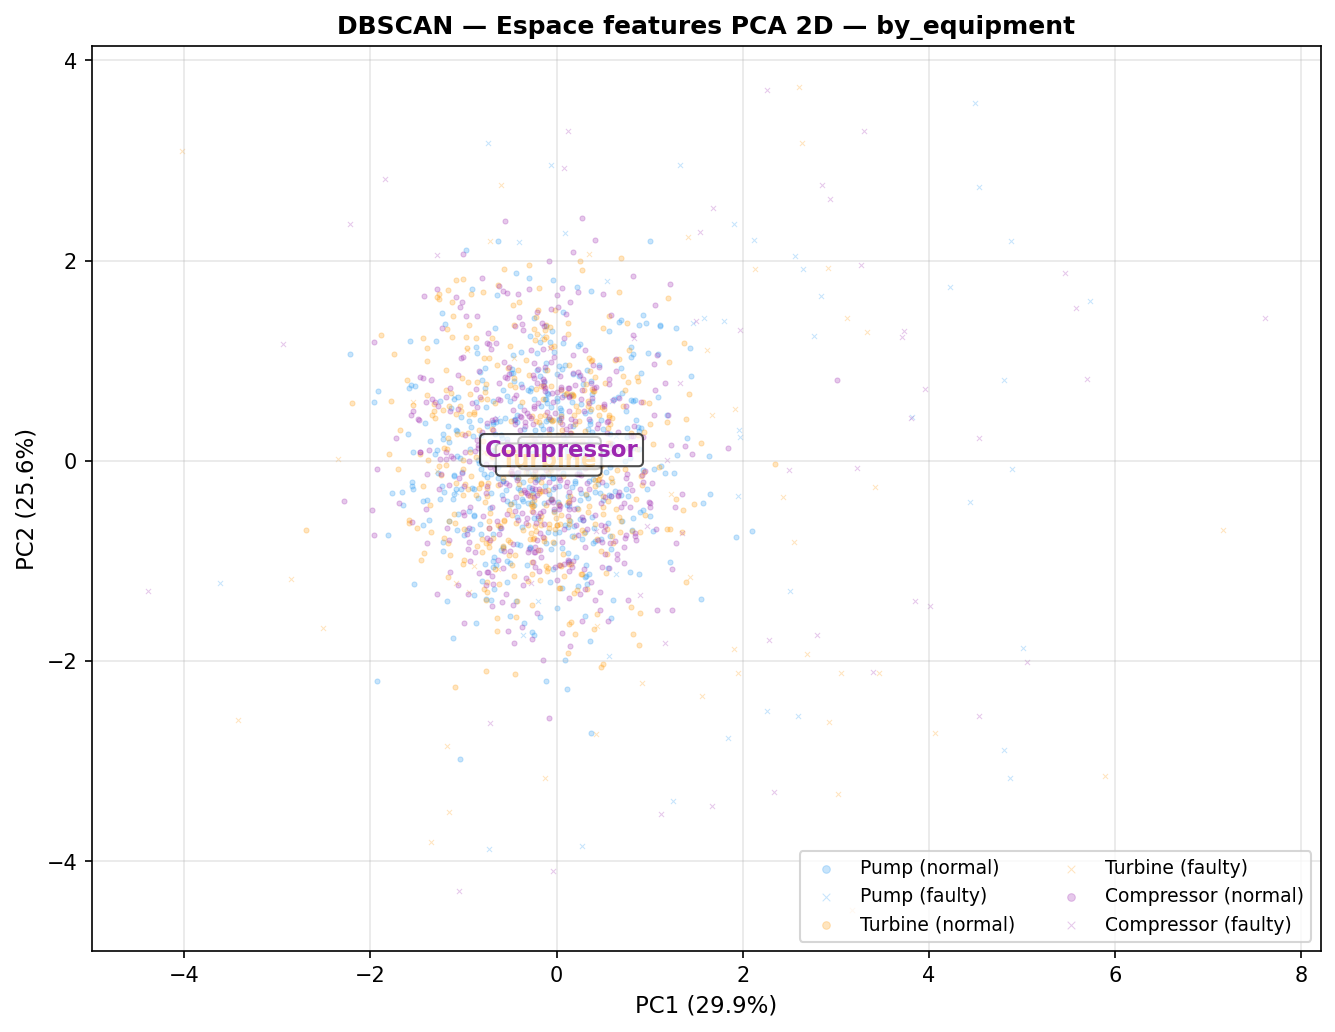

In [8]:
# Section 8 — Espace des features (PCA 2D)
# Visualise la distribution des 3 tâches dans l'espace 2D PCA
# Permet de voir la compacité des clusters (où DBSCAN place ses core points)

if DATA_AVAILABLE and len(X_tests_raw) == 3:
    X_all      = np.concatenate(X_tests_raw, axis=0)
    y_all      = np.concatenate(y_tests_raw, axis=0)
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(3)
    ])

    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_equipment",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=11,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown("> ⚠️ **Section 8 ignorée** — données non disponibles."))
    print("[SKIP] feature_space_pca.png")

In [9]:
# Section 9 — Tableau récapitulatif + Discussion RAM

ram_ko = ram_b / 1024
excess_ko = max(0, (ram_b - RAM_LIMIT_BYTES) / 1024)
status_ram = "⚠️" if ram_b > RAM_LIMIT_BYTES else ""

display(Markdown("### Résultats finaux — DBSCAN — monitoring/by_equipment (exp_008)"))

recap_table = f'''
| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_core×d |
|--------|------|------|-----|---------|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {auroc_avg:.4f} | {ram_ko:.2f} Ko {status_ram} | {lat:.5f} ms | {n_params} |
'''
display(Markdown(recap_table))

# Discussion RAM détaillée (FIXME gap2)
display(Markdown(f'''### Discussion — Contrainte embarquée (FIXME gap2)

DBSCAN atteint la meilleure AUROC (**{auroc_avg:.4f}**) et un bon AA ({aa:.4f}) sur ce scénario,
mais sa RAM peak de **{ram_ko:.1f} Ko dépasse la contrainte de {RAM_LIMIT_BYTES/1024:.0f} Ko du STM32N6**
(dépassement : {excess_ko:.1f} Ko).

**Pistes d'optimisation à explorer (hors périmètre Sprint 7, à planifier Sprint 10 MCU) :**

1. **Buffer borné de core points** — sélection top-N (ex. N=500) des points les plus représentatifs
   par tâche : N × d × 4 B = 500 × 4 × 4 = 8 Ko, compatible budget 64 Ko.
2. **Streaming DBSCAN** — variante incrémentale avec oubli explicite des anciens core points
   (Ester et al. 2003, incremental DBSCAN).
3. **Quantification INT8 des core points** (Gap 3) — diviser par 4 l'empreinte FP32.
4. **Substitution par Mahalanobis** — RAM=1.5 Ko, AUROC=0.9718 : candidat plus embarqué.

`TODO(fred)` : En contexte industriel Edge Spectrum, quelle RAM effective est disponible ?
Si > 100 Ko, DBSCAN reste pertinent malgré le dépassement STM32N6.
'''))

print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : {RAM_LIMIT_BYTES} B ({RAM_LIMIT_BYTES/1024:.0f} Ko)")
print(f"  Dépassement    : {ram_b - RAM_LIMIT_BYTES} B (+{excess_ko:.2f} Ko)")
print(f"  DBSCAN occupe  : {ram_b / RAM_LIMIT_BYTES * 100:.1f}% du budget RAM STM32N6")
print()
print("  FIXME(gap2) : DBSCAN non déployable direct sur STM32N6.")
print("                Voir discussion ci-dessus pour les pistes d'optimisation.")
print()

# Vérification des critères d'acceptation (S7-06)
print("=" * 60)
print("  Critères d'acceptation (S7-06)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "auroc_curve.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9557) < 0.005 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9557)")
print(f"  [{'OK' if abs(af) < 0.001 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0)")
print(f"  [{'OK' if abs(bwt - 0.0010) < 0.005 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ +0.0010)")
print(f"  [{'OK' if abs(auroc_avg - 0.9786) < 0.005 else 'WARN'}] AUROC  = {auroc_avg:.4f} (attendu ≈ 0.9786)")
print(f"  [{'FAIL (Gap2)' if ram_b > RAM_LIMIT_BYTES else 'OK'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — DBSCAN — monitoring/by_equipment (exp_008)


| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_core×d |
|--------|------|------|-----|---------|-------|-----------|----------|
| DBSCAN | 0.9557 | 0.0000 | +0.0010 | 0.9786 | 71.91 Ko ⚠️ | 0.42320 ms | 5412 |


### Discussion — Contrainte embarquée (FIXME gap2)

DBSCAN atteint la meilleure AUROC (**0.9786**) et un bon AA (0.9557) sur ce scénario,
mais sa RAM peak de **71.9 Ko dépasse la contrainte de 64 Ko du STM32N6**
(dépassement : 7.9 Ko).

**Pistes d'optimisation à explorer (hors périmètre Sprint 7, à planifier Sprint 10 MCU) :**

1. **Buffer borné de core points** — sélection top-N (ex. N=500) des points les plus représentatifs
   par tâche : N × d × 4 B = 500 × 4 × 4 = 8 Ko, compatible budget 64 Ko.
2. **Streaming DBSCAN** — variante incrémentale avec oubli explicite des anciens core points
   (Ester et al. 2003, incremental DBSCAN).
3. **Quantification INT8 des core points** (Gap 3) — diviser par 4 l'empreinte FP32.
4. **Substitution par Mahalanobis** — RAM=1.5 Ko, AUROC=0.9718 : candidat plus embarqué.

`TODO(fred)` : En contexte industriel Edge Spectrum, quelle RAM effective est disponible ?
Si > 100 Ko, DBSCAN reste pertinent malgré le dépassement STM32N6.


  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 73638 B = 71.91 Ko
  Budget STM32N6 : 65536 B (64 Ko)
  Dépassement    : 8102 B (+7.91 Ko)
  DBSCAN occupe  : 112.4% du budget RAM STM32N6

  FIXME(gap2) : DBSCAN non déployable direct sur STM32N6.
                Voir discussion ci-dessus pour les pistes d'optimisation.

  Critères d'acceptation (S7-06)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] auroc_curve.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.9557  (attendu ≈ 0.9557)
  [OK] AF     = 0.0000  (attendu ≈ 0.0)
  [OK] BWT    = +0.0010 (attendu ≈ +0.0010)
  [OK] AUROC  = 0.9786 (attendu ≈ 0.9786)
  [FAIL (Gap2)] RAM    = 71.91 Ko (contrainte ≤ 64 Ko)
  [OK] Latence= 0.42320 ms (contrainte ≤ 100 ms)
